# Coleta dos Dados

## Brasil Industrial Geral Numero Indice periodo 01-2002 - 12-2022

### Coleta via API

In [2]:
import pandas as pd
import requests
# A URL que você encontrou na imagem (Parâmetros para a API)
api_url = "https://apisidra.ibge.gov.br/values/t/8159/n1/all/v/11599/p/all/c544/129314/d/v11599%201"

# Coletando os dados Industria Geral Brasil via API
response = requests.get(api_url)
data = response.json()

# Transformando em um DataFrame (Tabela)
df_BrasilGeral = pd.DataFrame(data)
#print(df_BrasilGeral.head())

# Limpeza rápida: a primeira linha do IBGE é sempre o cabeçalho descritivo
df_BrasilGeral.columns = df_BrasilGeral.iloc[0]
print(df_BrasilGeral.head())

df_BrasilGeral = df_BrasilGeral.iloc[1:]
#print(df_BrasilGeral.head())



0  Nível Territorial (Código)  Nível Territorial  Unidade de Medida (Código)  \
0  Nível Territorial (Código)  Nível Territorial  Unidade de Medida (Código)   
1                           1             Brasil                          30   
2                           1             Brasil                          30   
3                           1             Brasil                          30   
4                           1             Brasil                          30   

0  Unidade de Medida  Valor  Brasil (Código)  Brasil  Variável (Código)  \
0  Unidade de Medida  Valor  Brasil (Código)  Brasil  Variável (Código)   
1      Número-índice   72.4                1  Brasil              11599   
2      Número-índice   69.7                1  Brasil              11599   
3      Número-índice   77.4                1  Brasil              11599   
4      Número-índice   79.6                1  Brasil              11599   

0                          Variável  Mês (Código)             Mês  \

In [3]:
# Selecionando apenas o que importa: Data (Mês) e o Valor do Índice
BrasilGeral = df_BrasilGeral[['Mês (Código)', 'Valor']].copy()
BrasilGeral.columns = ['Data', 'Indice']
#print(BrasilGeral.head())

# Convertendo para o formato correto
BrasilGeral['Data'] = pd.to_datetime(BrasilGeral['Data'], format='%Y%m')
BrasilGeral['Indice'] = pd.to_numeric(BrasilGeral['Indice'], errors='coerce')
#Organizando por data
BrasilGeral = BrasilGeral.set_index('Data').sort_index()

print("Coleta Brasil Industrial Geral")
print(BrasilGeral.head())


Coleta Brasil Industrial Geral
            Indice
Data              
2002-01-01    72.4
2002-02-01    69.7
2002-03-01    77.4
2002-04-01    79.6
2002-05-01    80.4


# Pré Processamento

## Brasil Industrial Geral Numero Indice periodo 01-2002 - 12-2022

### Checar se tem dados de meses faltando

In [4]:
# Forçando a frequência mensal (Month Start)
BrasilGeral = BrasilGeral.asfreq('MS')
print(BrasilGeral)

# 3. Checando se o asfreq encontrou algum mês faltando
buracos = BrasilGeral['Indice'].isnull().sum()
if buracos > 0:
    print(f"Meses Faltantes: {buracos} ")
    BrasilGeral['Indice'] = BrasilGeral['Indice'].interpolate() 
else:
    print("Sem 0's. DataFrame Pronto para uso")


            Indice
Data              
2002-01-01    72.4
2002-02-01    69.7
2002-03-01    77.4
2002-04-01    79.6
2002-05-01    80.4
...            ...
2022-08-01    96.0
2022-09-01    91.8
2022-10-01    91.3
2022-11-01    87.0
2022-12-01    78.2

[252 rows x 1 columns]
Sem 0's. DataFrame Pronto para uso


### Checar se tem dados de datas duplicadas

In [5]:
# Verifica se existe alguma data repetida (retorna True ou False)
duplicata = BrasilGeral.index.duplicated().any()

if duplicata:
    quantidade = BrasilGeral.index.duplicated().sum()
    print(f"Existem {quantidade} datas duplicadas")
    BrasilGeral = BrasilGeral[~BrasilGeral.index.duplicated(keep='first')]
else:
    print("Não existem datas duplicadas. O calendário está limpo!")

Não existem datas duplicadas. O calendário está limpo!


### Outliers 

In [6]:
#Valores negativos!
import numpy as np
# --- SANEAMENTO DE VALORES IMPOSSÍVEIS ---

# 1. Checar se existem zeros ou negativos
invalidos = (BrasilGeral['Indice'] <= 0).sum()

if invalidos > 0:
    print(f"Existem {invalidos} valor(es) zero ou negativo(s). Tratando como 'vazio' (NaN)...")
    # Transforma apenas os valores problemáticos em NaN
    BrasilGeral.loc[BrasilGeral['Indice'] <= 0, 'Indice'] = np.nan
    BrasilGeral['Indice'] = BrasilGeral['Indice'].interpolate()

else:
    print("Não existem valores zero ou negativos na série. A produção está positiva!")


Não existem valores zero ou negativos na série. A produção está positiva!


In [7]:
#Valores Distonantes, distintos, possiveis outliers com base na media dos 6meses anteriores e 6 meses posteriores

# Criar média e desvio padrão móvel de 12 meses
# O 'center=True' olha 6 meses para trás e 6 para frente
rolling_mean = BrasilGeral['Indice'].rolling(window=12, center=True).mean()
rolling_std = BrasilGeral['Indice'].rolling(window=12, center=True).std()

# Calcular o Z-Score (quantos desvios o ponto está longe da média)
z_scores = (BrasilGeral['Indice'] - rolling_mean) / rolling_std

# Checagem dos Outliers (|z| > 3)
outliers_encontrados = z_scores.abs() > 3

if outliers_encontrados.any():
    qtd_outliers = outliers_encontrados.sum()
    print(f"Numero de possiveis outliers: {qtd_outliers} ")
    
    # Mostrar quais datas são para você conferir
    print(BrasilGeral[outliers_encontrados].index)
    
    # Transforma esses saltos em "vazio" para serem corrigidos depois
    BrasilGeral.loc[outliers_encontrados, 'Indice'] = np.nan
    BrasilGeral['Indice'] = BrasilGeral['Indice'].interpolate()
else:
    print("Nenhum salto absurdo detectado. Dados Normais")

Nenhum salto absurdo detectado. Dados Normais


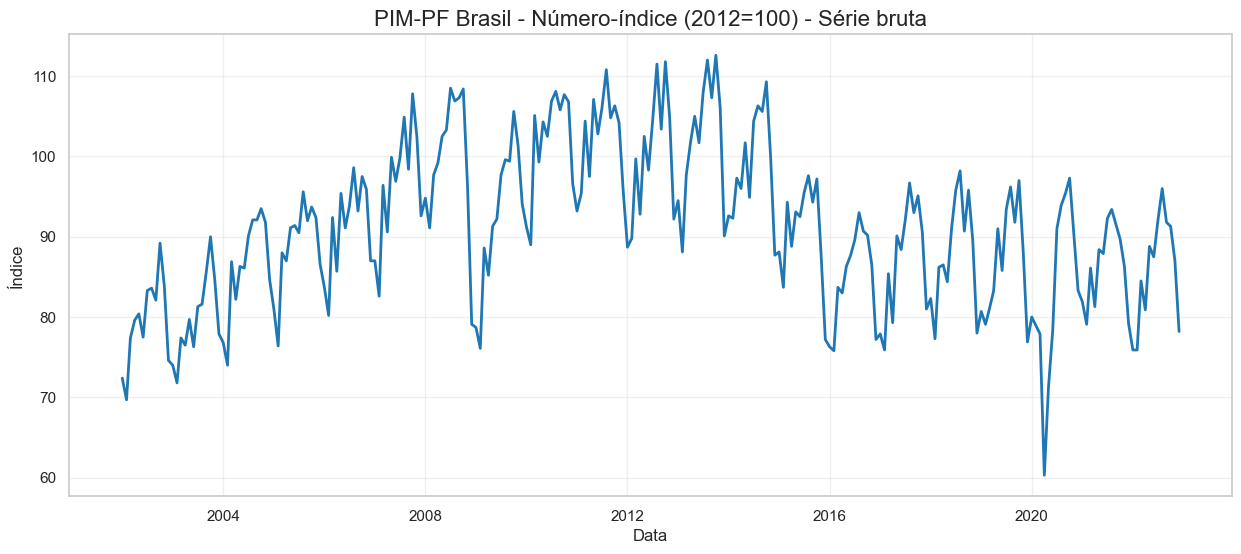

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definindo o estilo e o tamanho da imagem (proporção larga como a sua)
plt.figure(figsize=(15, 6))
sns.set_theme(style="whitegrid") # Cria esse fundo com grades claras

# 2. Plotando a linha (o 'Indice' que limpamos antes)
plt.plot(BrasilGeral.index, BrasilGeral['Indice'], color='#1f77b4', linewidth=2)

# 3. Personalizando os textos (Exatamente como na sua imagem)
plt.title('PIM-PF Brasil - Número-índice (2012=100) - Série bruta', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Índice', fontsize=12)

# 4. Ajuste fino da grade (deixando ela mais suave)
plt.grid(True, alpha=0.3)

# Exibir o gráfico
plt.show()

# Analise Exploratoria dos Dados via API

## Brasil Industrial Geral Numero Indice (Periodo Jan-2002 a Dez-2022)

### Graficos

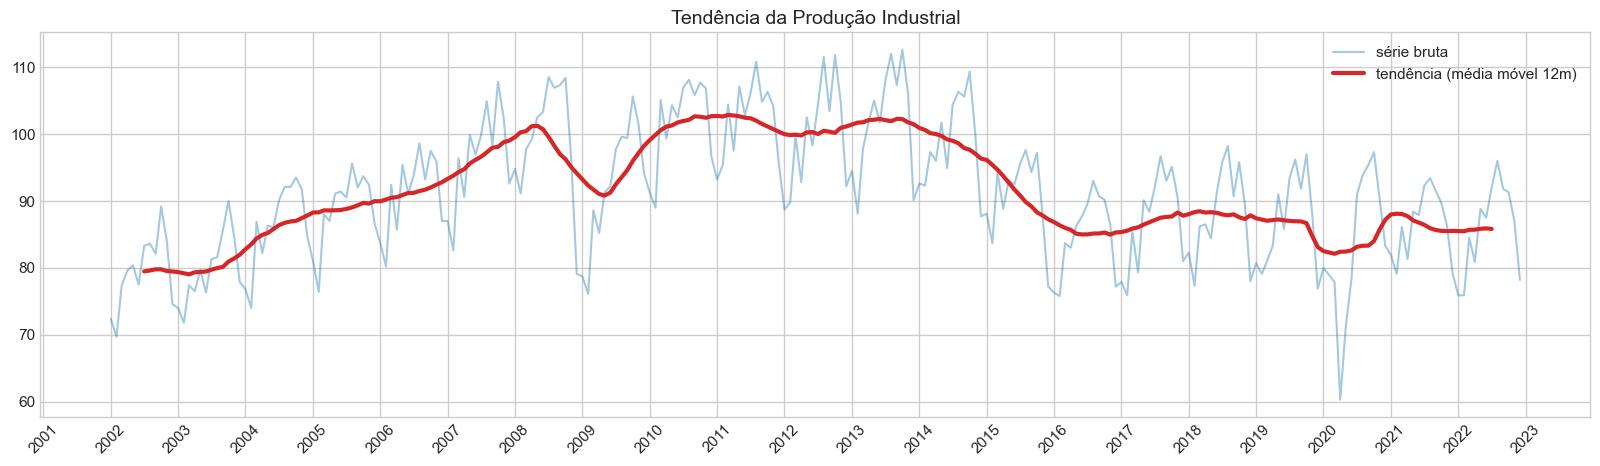

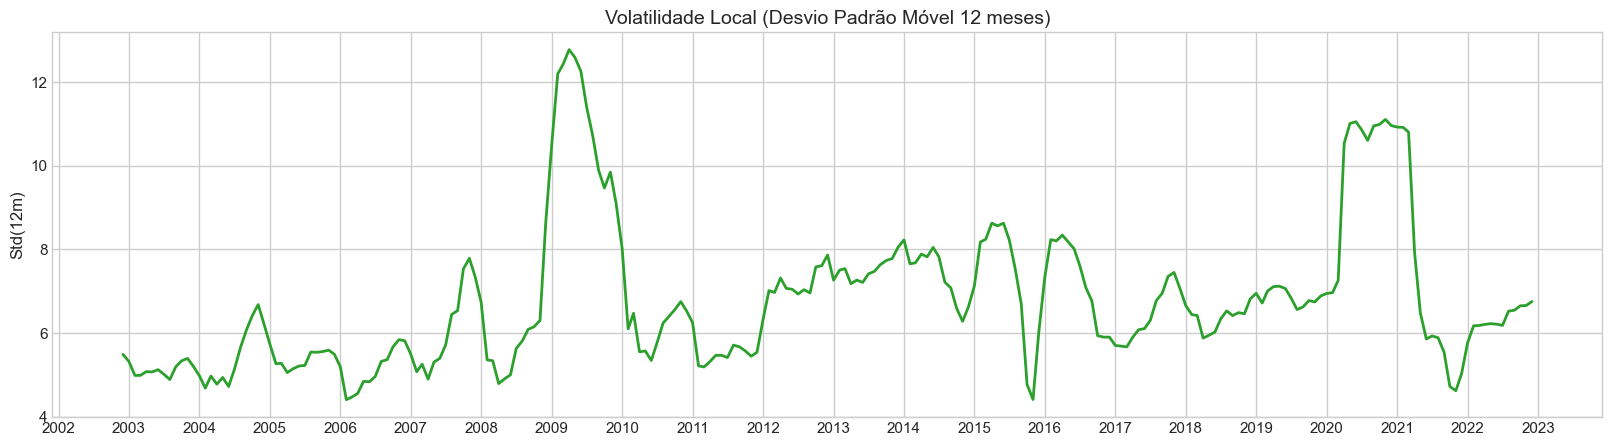

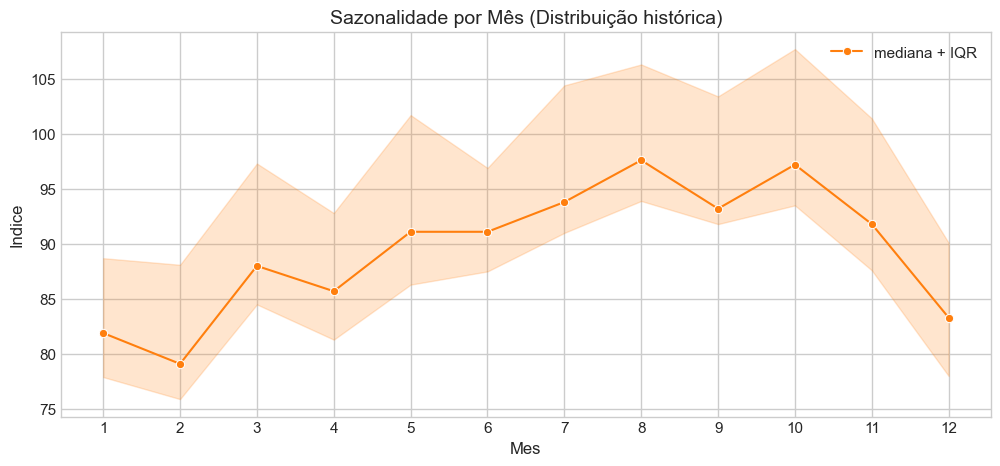

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
# Configuração de estilo geral
plt.style.use('seaborn-v0_8-whitegrid')

# --- 1. GRÁFICO DE TENDÊNCIA (Média Móvel 12m) ---
plt.figure(figsize=(20, 5))
plt.plot(BrasilGeral.index, BrasilGeral['Indice'], alpha=0.4, label='série bruta', color='tab:blue')
plt.plot(BrasilGeral.index, BrasilGeral['Indice'].rolling(12, center=True).mean(), 
         color='tab:red', linewidth=3, label='tendência (média móvel 12m)')
ax = plt.gca() # Pega o "eixo" do gráfico para podermos configurá-lo
ax.xaxis.set_major_locator(mdates.YearLocator()) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45) # 4. Inclina os anos em 45 graus para eles não se atropelarem [cite: 1148, 1149]
plt.title('Tendência da Produção Industrial', fontsize=14)
plt.legend()
plt.show()

# --- 2. GRÁFICO DE VOLATILIDADE (Desvio Padrão Móvel) ---
plt.figure(figsize=(20, 5))
plt.plot(BrasilGeral.index, BrasilGeral['Indice'].rolling(12).std(), color='tab:green', linewidth=2)
plt.title('Volatilidade Local (Desvio Padrão Móvel 12 meses)', fontsize=14)
ax = plt.gca() # Pega o "eixo" do gráfico para podermos configurá-lo
ax.xaxis.set_major_locator(mdates.YearLocator()) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.ylabel('Std(12m)')
plt.show()

# --- 3. GRÁFICO DE SAZONALIDADE (Distribuição Mensal) ---
# Primeiro, criamos uma coluna apenas com o mês (1 a 12)
BrasilGeral['Mes'] = BrasilGeral.index.month
plt.figure(figsize=(12, 5))
sns.lineplot(data=BrasilGeral, x='Mes', y='Indice', estimator='median', errorbar=('pi', 50), 
             color='tab:orange', marker='o', label='mediana + IQR')
plt.xticks(range(1, 13))
plt.title('Sazonalidade por Mês (Distribuição histórica)', fontsize=14)
plt.show()

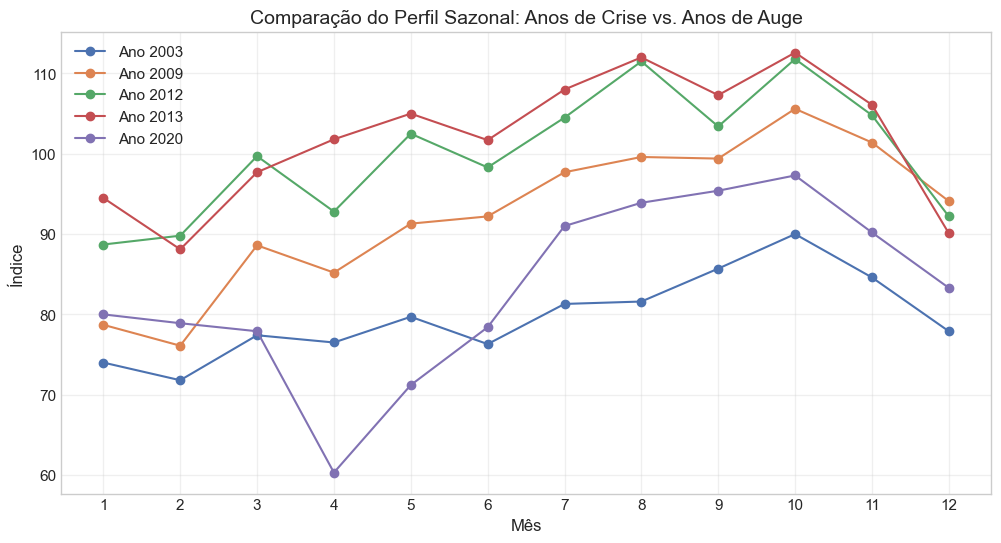

In [10]:
import matplotlib.pyplot as plt

# Criando um gráfico para comparar os anos que você escolheu
anos_para_comparar = [2003, 2009, 2012, 2013, 2020]

plt.figure(figsize=(12, 6))

for ano in anos_para_comparar:
    # Filtramos apenas os dados daquele ano específico
    dados_ano = BrasilGeral[BrasilGeral.index.year == ano]
    
    # Plotamos: o eixo X será apenas o mês (1 a 12)
    plt.plot(dados_ano.index.month, dados_ano['Indice'], marker='o', label=f'Ano {ano}')

plt.title('Comparação do Perfil Sazonal: Anos de Crise vs. Anos de Auge', fontsize=14)
plt.xlabel('Mês')
plt.ylabel('Índice')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Decomposição STL

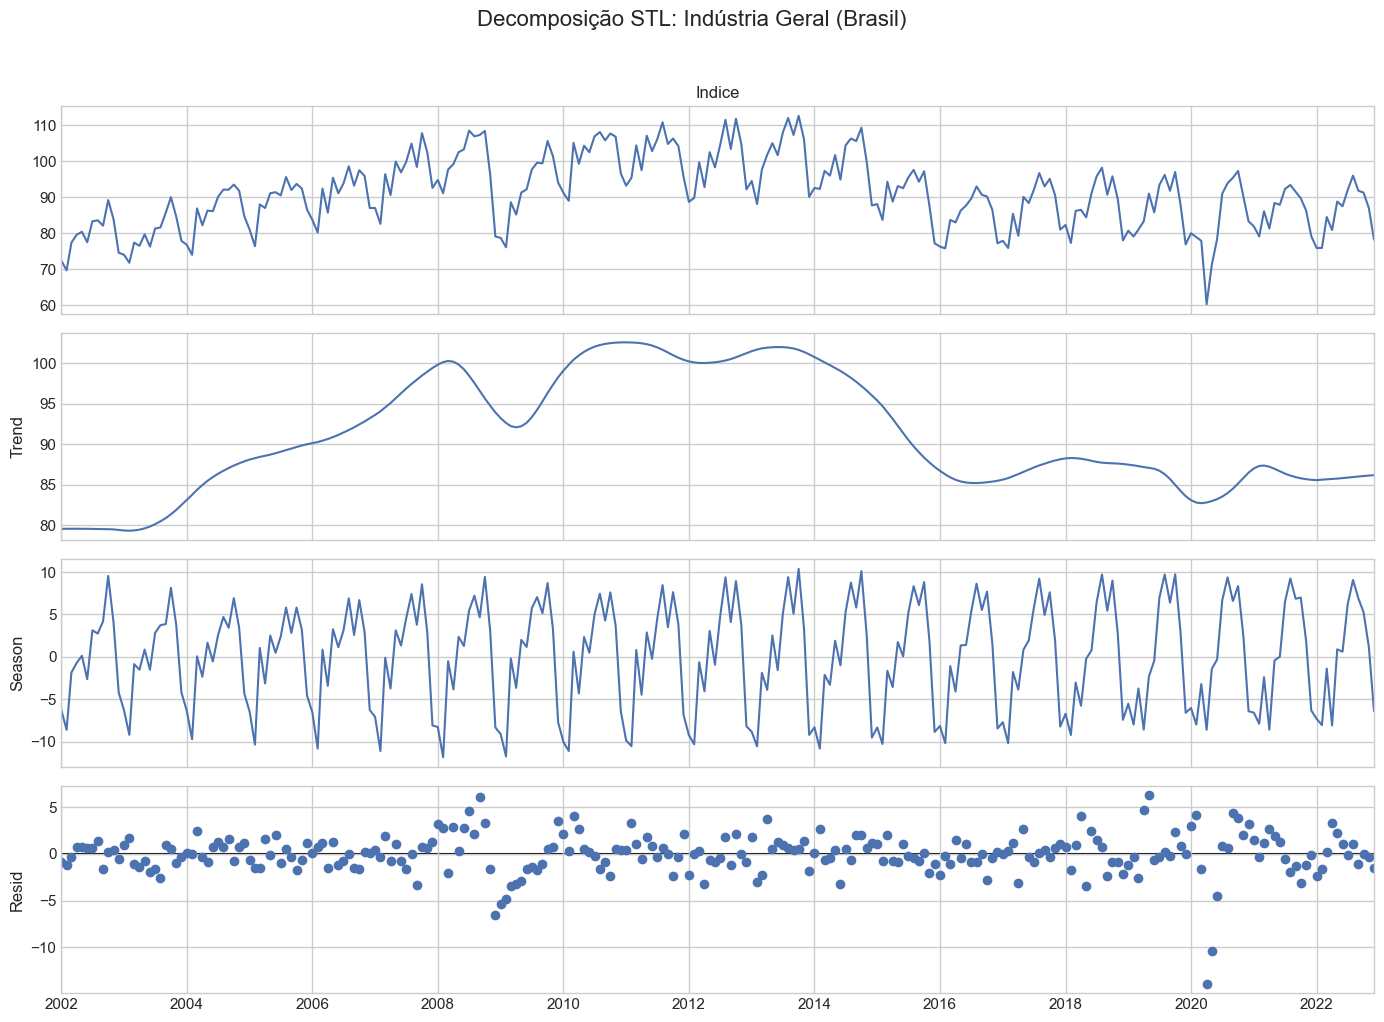

In [11]:
from statsmodels.tsa.seasonal import STL

# Executando a decomposição
# O 'period=12' avisa ao Python que o padrão se repete a cada 12 meses [cite: 728]
stl = STL(BrasilGeral['Indice'], period=12)
res = stl.fit()

# Gerando o gráfico com os 4 componentes
fig = res.plot()
fig.set_size_inches(14, 10) # Ajusta o tamanho para caber no seu relatório
plt.suptitle('Decomposição STL: Indústria Geral (Brasil)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show() 

### Variáveis Derivadas (EVM e AVA)

In [12]:
# 1. Calculando a EVM (Variação Mensal %)
# Compara o mês atual com o mês imediatamente anterior
BrasilGeral['EVM'] = BrasilGeral['Indice'].pct_change(1) * 100

# 2. Calculando a AVA (Variação Acumulada 12 meses %)
# Compara o mês atual com o mesmo mês do ano anterior
BrasilGeral['AVA'] = BrasilGeral['Indice'].pct_change(12) * 100

# Visualizando os novos dados
print(BrasilGeral[['Indice', 'EVM', 'AVA']].tail())

            Indice        EVM       AVA
Data                                   
2022-08-01    96.0   4.347826  2.783726
2022-09-01    91.8  -4.375000  0.327869
2022-10-01    91.3  -0.544662  1.783724
2022-11-01    87.0  -4.709748  0.811124
2022-12-01    78.2 -10.114943 -1.262626


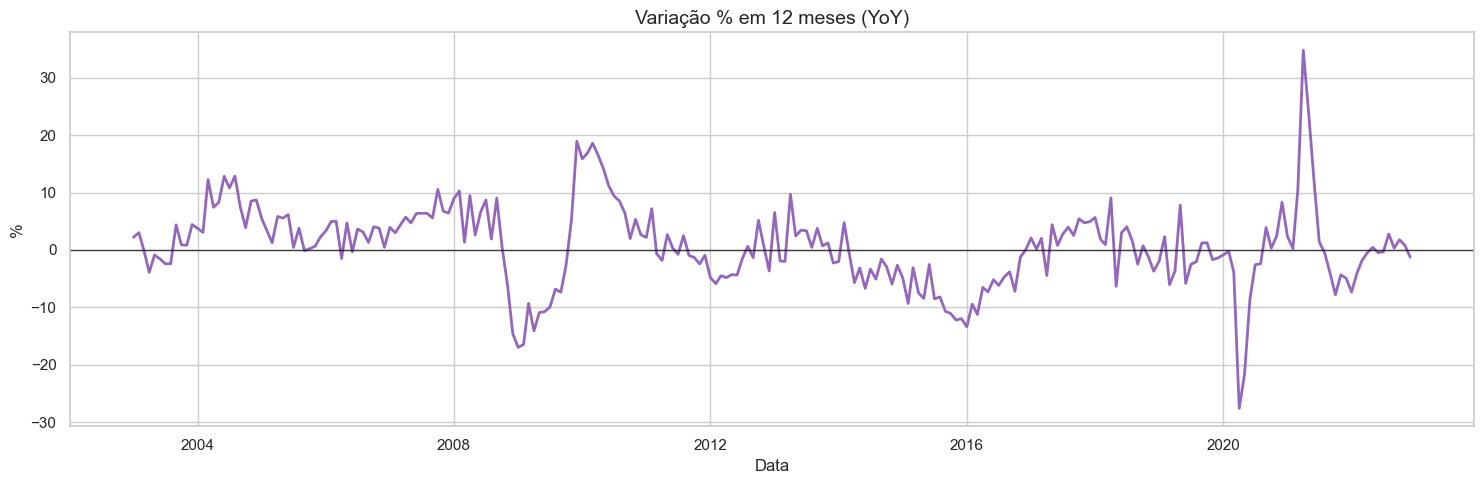

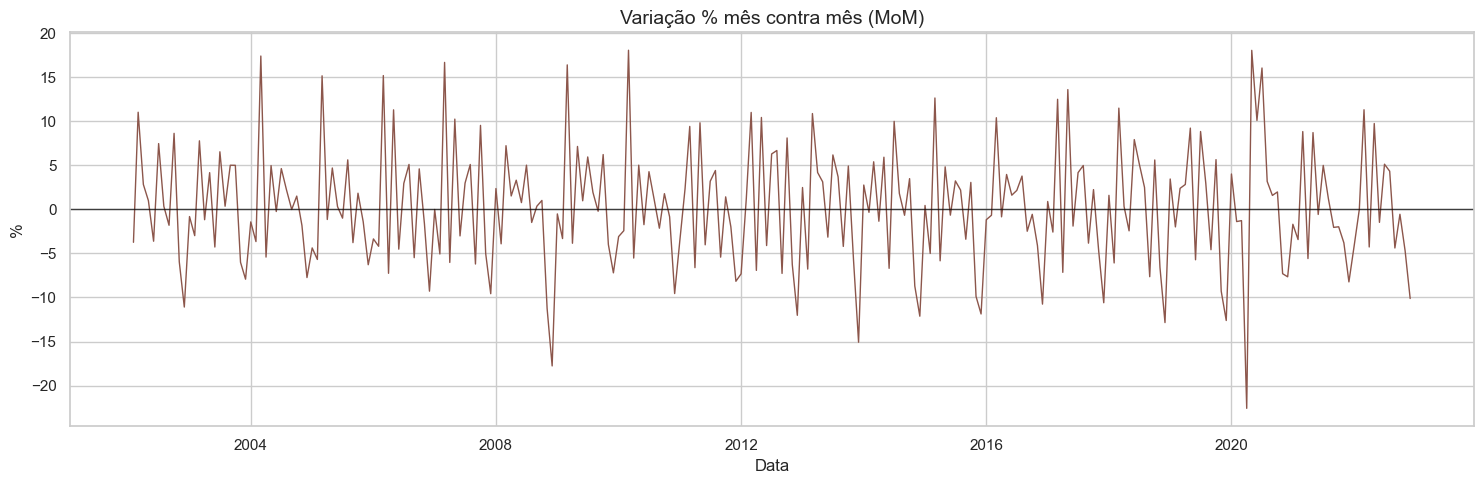

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo para parecer profissional como o seu exemplo
sns.set_theme(style="whitegrid")

# --- 1. GRÁFICO DE VARIAÇÃO ACUMULADA (AVA / YoY %) ---
plt.figure(figsize=(15, 5))
plt.plot(BrasilGeral.index, BrasilGeral['AVA'], color='#9467bd', linewidth=2) # Roxo como na imagem 4
plt.axhline(0, color='black', linewidth=1, alpha=0.7) # Linha de referência no zero
plt.title('Variação % em 12 meses (YoY)', fontsize=14)
plt.ylabel('%')
plt.xlabel('Data')
plt.tight_layout()
plt.show()

# --- 2. GRÁFICO DE VARIAÇÃO MENSAL (EVM / MoM %) ---
plt.figure(figsize=(15, 5))
plt.plot(BrasilGeral.index, BrasilGeral['EVM'], color='#8c564b', linewidth=1) # Marrom como na imagem 5
plt.axhline(0, color='black', linewidth=1, alpha=0.7)
plt.title('Variação % mês contra mês (MoM)', fontsize=14)
plt.ylabel('%')
plt.xlabel('Data')
plt.tight_layout()
plt.show()

### Testes de Estacionariedade ADF

In [14]:
from statsmodels.tsa.stattools import adfuller

def testar_estacionariedade(serie, nome_serie):
    print(f"--- Teste ADF: {nome_serie} ---")
    resultado = adfuller(serie.dropna()) # O dropna garante que meses vazios não quebrem o teste
    
    p_valor = resultado[1]
    estatistica_adf = resultado[0]
    
    print(f'Estatística ADF: {estatistica_adf:.4f}')
    print(f'P-valor: {p_valor:.4f}')
    
    # Interpretando o resultado (Regra de Ouro: 5%)
    if p_valor <= 0.05:
        print("A série é ESTACIONÁRIA (p <= 0.05).")
    
    else:
        print("A série NÃO é estacionária (p > 0.05).")
        print("Aplicar a Diferenciação (diff) ou Log.")

# Rodando para a sua série principal
testar_estacionariedade(BrasilGeral['Indice'], "Produção Industrial Bruta")

--- Teste ADF: Produção Industrial Bruta ---
Estatística ADF: -2.1197
P-valor: 0.2367
A série NÃO é estacionária (p > 0.05).
Aplicar a Diferenciação (diff) ou Log.


### Filtro Diferenciação e Logaritmico

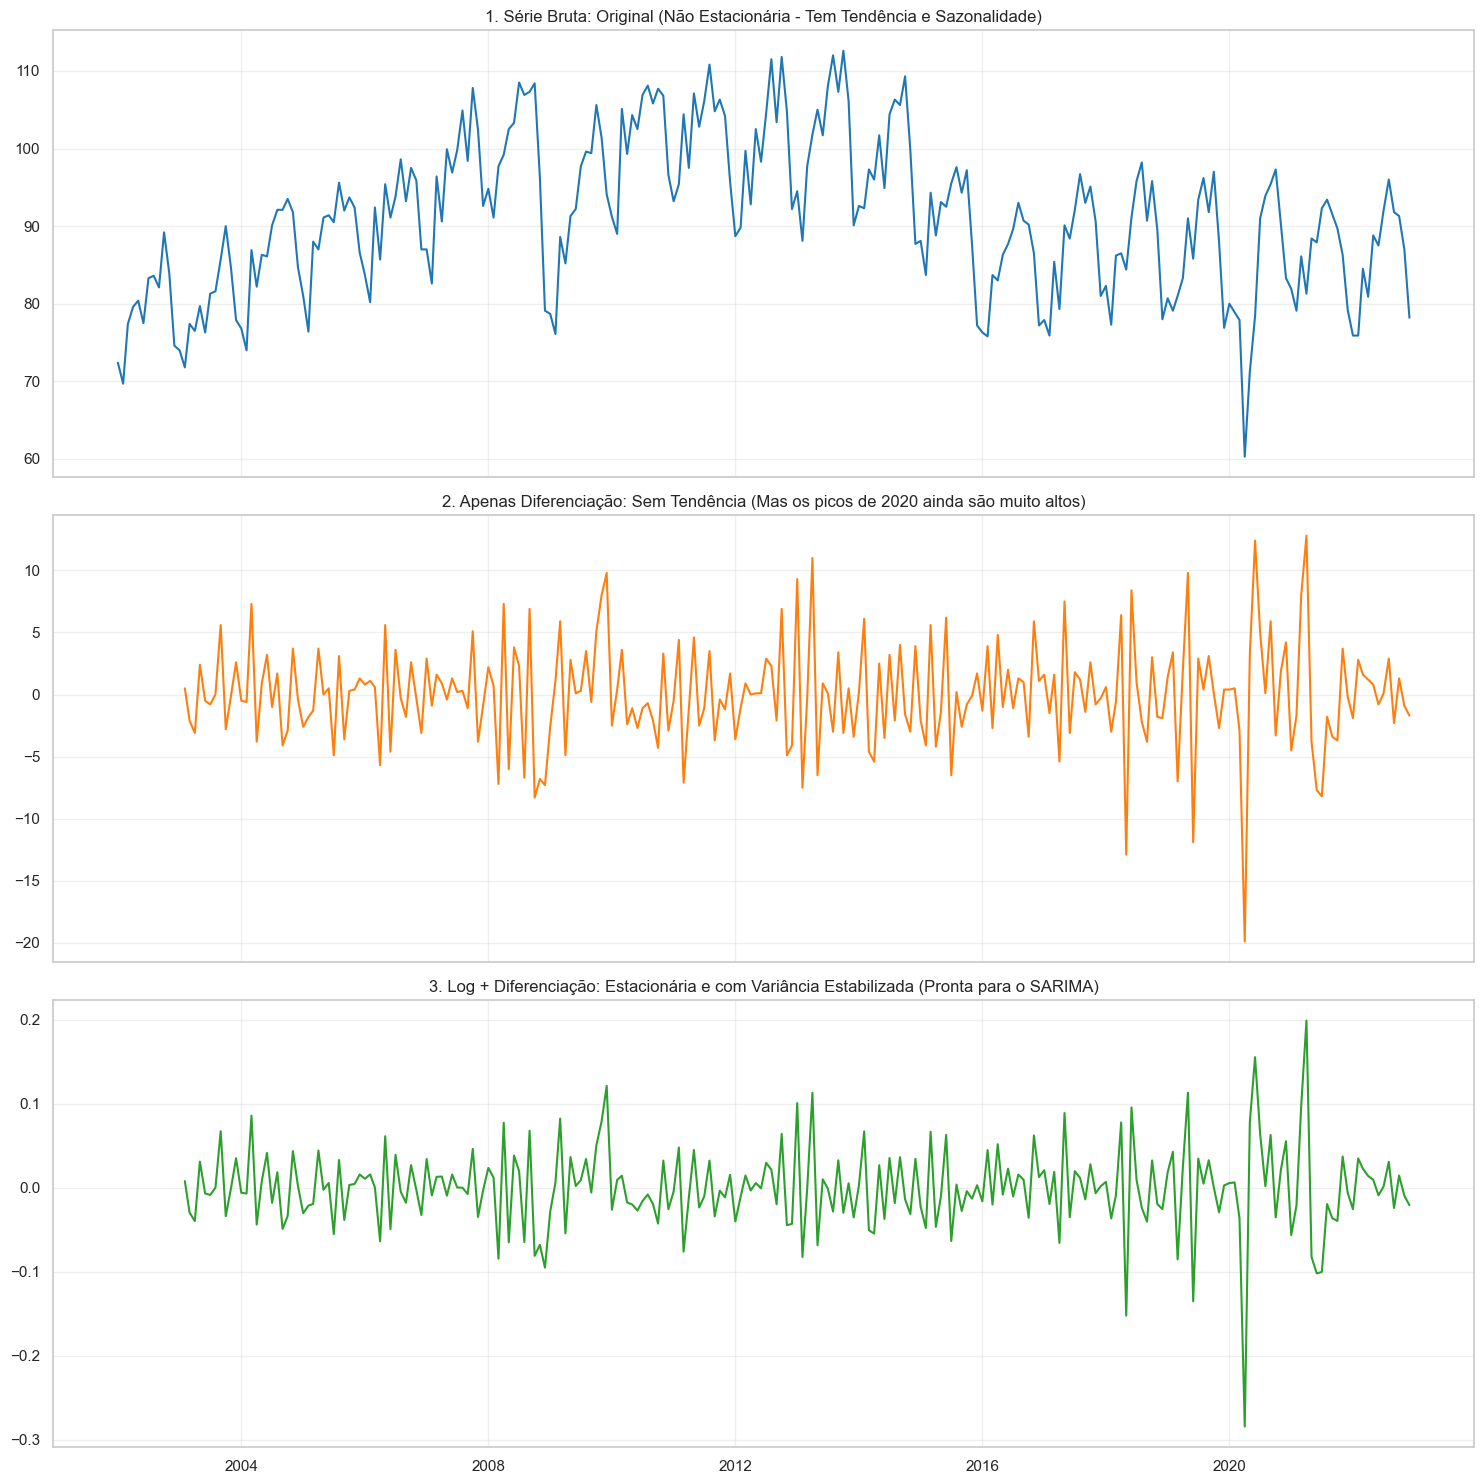

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Criando a versão apenas com Diferenciação (Simples + Sazonal)
# Isso remove a tendência e o padrão de 12 meses
serie_so_diff = BrasilGeral['Indice'].diff().diff(12)

# 2. Criando a versão Logaritmo + Diferenciação (A mais completa)
# Primeiro achata os picos com Log, depois remove a tendência
serie_log_diff = np.log(BrasilGeral['Indice']).diff().diff(12)

# --- Plotando o Comparativo ---
fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharex=True)

# Gráfico 1: Série Bruta (Onde você começou)
axes[0].plot(BrasilGeral.index, BrasilGeral['Indice'], color='tab:blue')
axes[0].set_title('1. Série Bruta: Original (Não Estacionária - Tem Tendência e Sazonalidade)')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Apenas Diferenciação (Remove a "Escada")
axes[1].plot(BrasilGeral.index, serie_so_diff, color='tab:orange')
axes[1].set_title('2. Apenas Diferenciação: Sem Tendência (Mas os picos de 2020 ainda são muito altos)')
axes[1].grid(True, alpha=0.3)

# Gráfico 3: Log + Diferenciação (O "Padrão Ouro")
axes[2].plot(BrasilGeral.index, serie_log_diff, color='tab:green')
axes[2].set_title('3. Log + Diferenciação: Estacionária e com Variância Estabilizada (Pronta para o SARIMA)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
import numpy as np

# 1. Criando a série 'blindada' (Log + Diferença de 1 mês + Diferença de 12 meses)
# O dropna() é essencial porque a diferenciação cria 'buracos' no início da série
serie_para_modelo = np.log(BrasilGeral['Indice']).diff().diff(12).dropna()

# 2. Testando a estacionariedade de novo
testar_estacionariedade(serie_para_modelo, "Série Log-Diferenciada (Final)")

--- Teste ADF: Série Log-Diferenciada (Final) ---
Estatística ADF: -6.4196
P-valor: 0.0000
A série é ESTACIONÁRIA (p <= 0.05).


# Analise Exploratoria dos Dados (2ª Entrega com Analise dos dados CSV. baixados)

## 1. Primeira Analise: BRASIL 

Mais geral e simples
Periodos de Janeiro de 2002 até dezembro de 2022 (10 anos)
Abrange território nacional como um todo

### Ler da BaseDeDados PIM_PF_BR_2006_2022

#### Limpar os dados e organizar

In [53]:
import pandas as pd
import os

caminho = os.path.join('..', 'BaseDeDados', 'PIM_PF_BR_2006_2022.csv')

#Pula as primeiras linhas do cabeçalho poluido
df = pd.read_csv(caminho, sep=';', encoding='utf-8', skiprows=3)
#print(df.head())

## O axis=1 Tira a primeira coluna, limpar dados sem utilidade
df = df.drop(df.columns[0], axis=1)
df = df.iloc[:2]
#print(df)

meses = {
    'janeiro': '01',
    'fevereiro': '02',
    'março': '03',
    'abril': '04',
    'maio': '05',
    'junho': '06',
    'julho': '07',
    'agosto': '08',
    'setembro': '09',
    'outubro': '10',
    'novembro': '11',
    'dezembro': '12'
}

novas_datas = []

for col in df.columns:
    try:
        mes, ano = col.split()
        mes_num = meses[mes.lower()]
        data = f"{mes_num}/{ano}"
        novas_datas.append(data)
    except:
        novas_datas.append(col)  # caso não seja mês

df.loc['Data'] = novas_datas
#print(df)

# 2. SALVANDO O TÍTULO ANALISE
# Pegamos o valor da primeira linha, primeira coluna
titulo_analise = df.iloc[0, 1]
#print (titulo_analise)

# 3. Remove a linha 1 (informação sem utilizade - "Indústria Geral") Pode ser o titulo da analise?
# O axis=0 diz que é uma LINHA
df = df.drop(index=0)
#print(df)
linha_data = df.loc[['Data']]
resto = df.drop(index='Data')


df = pd.concat([linha_data, resto])
print(df)


     janeiro 2002 fevereiro 2002 março 2002 abril 2002 maio 2002 junho 2002  \
Data      01/2002        02/2002    03/2002    04/2002   05/2002    06/2002   
1        72,39269       69,71441   77,39979   79,59671  80,44721   77,49757   

     julho 2002 agosto 2002 setembro 2002 outubro 2002  ... março 2022  \
Data    07/2002     08/2002       09/2002      10/2002  ...    03/2022   
1      83,26465    83,58971      82,11028     89,17857  ...   84,49285   

     abril 2022 maio 2022 junho 2022 julho 2022 agosto 2022 setembro 2022  \
Data    04/2022   05/2022    06/2022    07/2022     08/2022       09/2022   
1      80,88910  88,83537   87,51774   91,95659    95,95352      91,81049   

     outubro 2022 novembro 2022 dezembro 2022  
Data      10/2022       11/2022       12/2022  
1        91,26549      87,03596      78,21171  

[2 rows x 252 columns]


#### Plotar os dados ano a ano

        Data    indice
0    01/2002  72.39269
1    02/2002  69.71441
2    03/2002  77.39979
3    04/2002  79.59671
4    05/2002  80.44721
..       ...       ...
247  08/2022  95.95352
248  09/2022  91.81049
249  10/2022  91.26549
250  11/2022  87.03596
251  12/2022  78.21171

[252 rows x 2 columns]
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


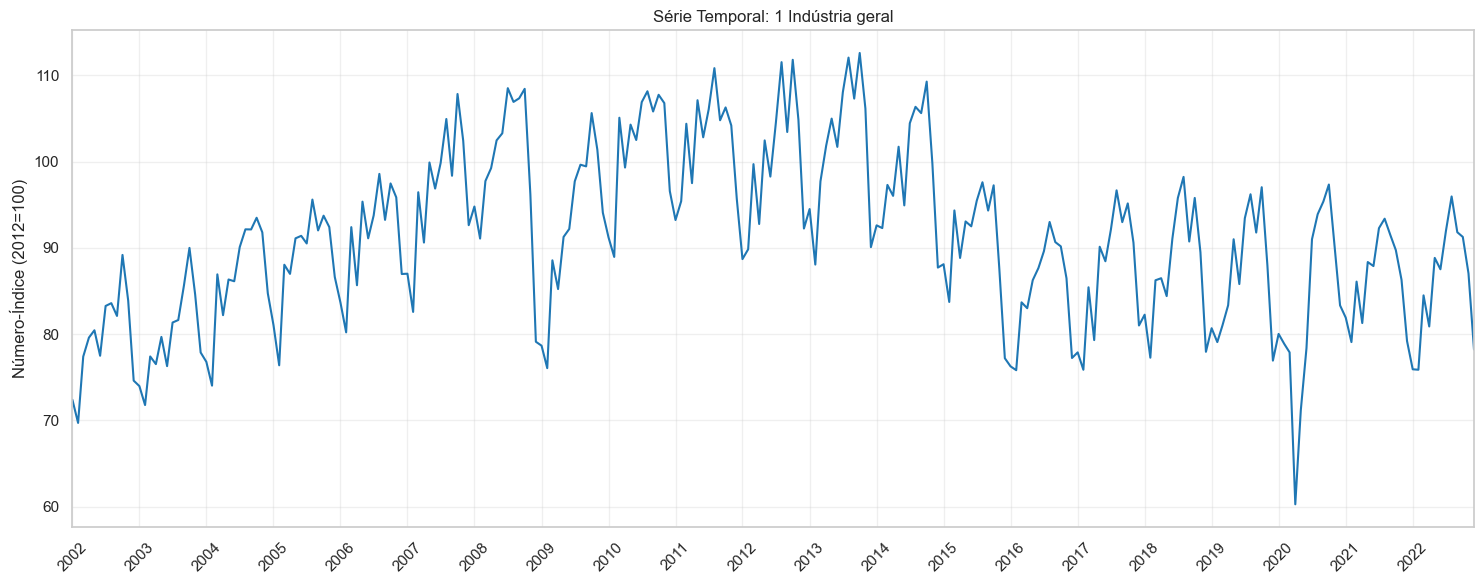

In [54]:
# TRANSPOSIÇÃO E CONVERSÃO
df_final = pd.DataFrame({
    'Data': df.iloc[0].values,
    'indice': df.iloc[1].values
})

df_final = df_final.dropna()

df_final['indice'] = (
    df_final['indice']
    .astype(str)
    .str.replace(',', '.')
    .astype(float)
)


print(df_final)
df_final['Data'] = pd.to_datetime(df_final['Data'], format='%m/%Y')
df_final = df_final.set_index('Data')
print(type(df_final.index))


# 7. GRÁFICO USANDO O TÍTULO SALVO
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Aumentamos um pouco o gráfico para caber mais informação
fig, ax = plt.subplots(figsize=(15, 6))

# Plotamos os dados
ax.plot(df_final.index, df_final['indice'], label='Índice de Produção', color='tab:blue')

# --- O PULO DO GATO ESTÁ AQUI ---
# 1. Força o marcador a aparecer de 1 em 1 ano (YearLocator(1))
ax.xaxis.set_major_locator(mdates.YearLocator(1)) 

# 2. Formata para mostrar apenas o Ano
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 3. Inclina 45 graus para os anos não baterem um no outro
plt.xticks(rotation=45)


plt.xlim(df_final.index.min(), df_final.index.max())

plt.title(f'Série Temporal: {titulo_analise}')
plt.ylabel('Número-Índice (2012=100)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Plotar para o ano de 2012

        Data    indice
0    01/2002  72,39269
1    02/2002  69,71441
2    03/2002  77,39979
3    04/2002  79,59671
4    05/2002  80,44721
..       ...       ...
247  08/2022  95,95352
248  09/2022  91,81049
249  10/2022  91,26549
250  11/2022  87,03596
251  12/2022  78,21171

[252 rows x 2 columns]


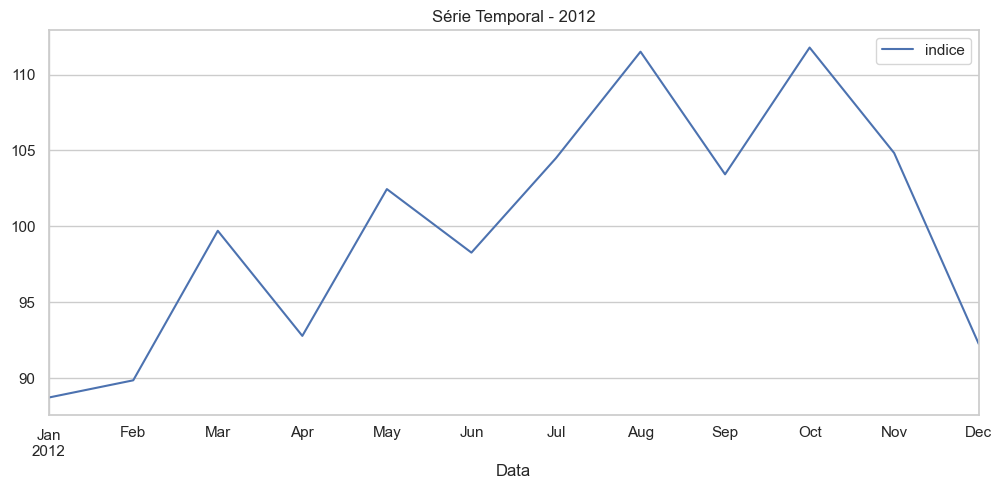

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
df_2012 = pd.DataFrame({
    'Data': df.iloc[0].values,
    'indice': df.iloc[1].values
})

print(df_2012)


df_2012 = df_2012.dropna()

df_2012['indice'] = (
    df_2012['indice']
    .astype(str)
    .str.replace(',', '.')
    .astype(float)
)

df_2012['Data'] = pd.to_datetime(df_2012['Data'], format='%m/%Y')
df_2012 = df_2012.set_index('Data')
#print(df_final)
df_2012 = df_final.loc['2012']
df_2012.plot(figsize=(12,5))
plt.title('Série Temporal - 2012')
plt.show()

### Vamos fazer a EDA

#### Tendencia

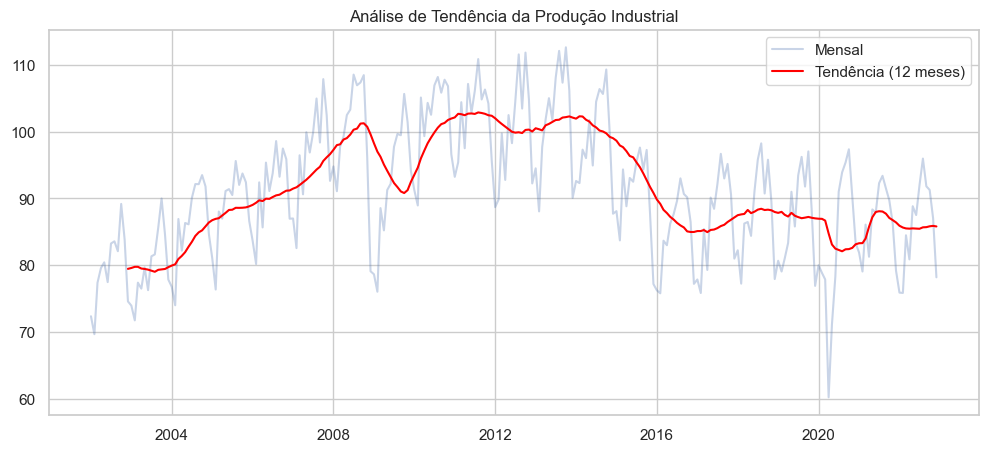

In [56]:
# Média móvel de 12 meses (uma janela de 1 ano)
df_final['media_movel'] = df_final['indice'].rolling(window=12).mean()

plt.figure(figsize=(12,5))
plt.plot(df_final.index, df_final['indice'], alpha=0.3, label='Mensal')
plt.plot(df_final.index, df_final['media_movel'], color='red', label='Tendência (12 meses)')
plt.title('Análise de Tendência da Produção Industrial')
plt.legend()
plt.show()

#### Sazonalidade

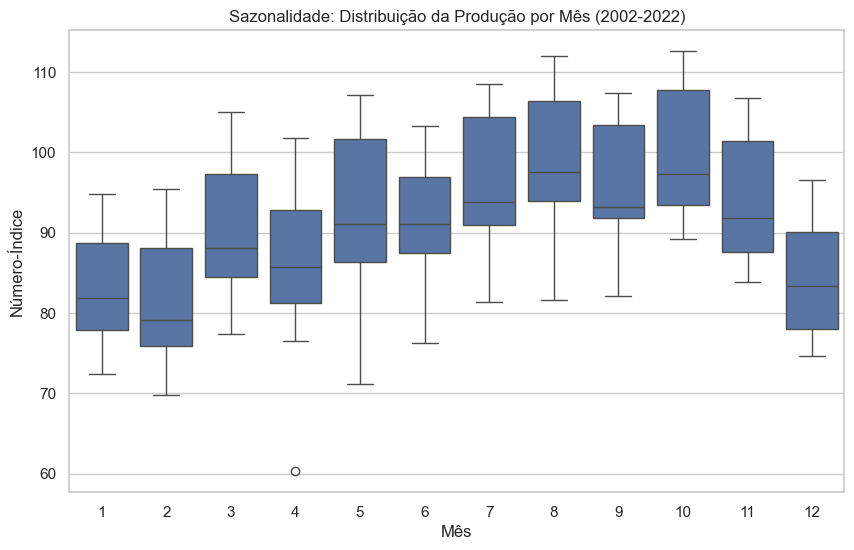

In [57]:
import seaborn as sns

# Extrair o mês para uma nova coluna
df_final['Mes_Num'] = df_final.index.month

plt.figure(figsize=(10,6))
sns.boxplot(x='Mes_Num', y='indice', data=df_final)
plt.title('Sazonalidade: Distribuição da Produção por Mês (2002-2022)')
plt.xlabel('Mês')
plt.ylabel('Número-Índice')
plt.show()

Tem sazonalidade... pico é em outubro novembro... e o vale no começo do ano.. Tem um outiliers no mes quadro... deve ser da pandemia...

#### Estacionaria a Serie?

In [58]:
from statsmodels.tsa.stattools import adfuller

resultado_adf = adfuller(df_final['indice'])
print(f'P-valor do Teste ADF: {resultado_adf[1]}')

# Se p-valor > 0.05, a série nao e estacionária (tem tendência)
# Se p-valor <= 0.05, a série e estacionária

P-valor do Teste ADF: 0.2370280896875011


#### 3. Ruido!

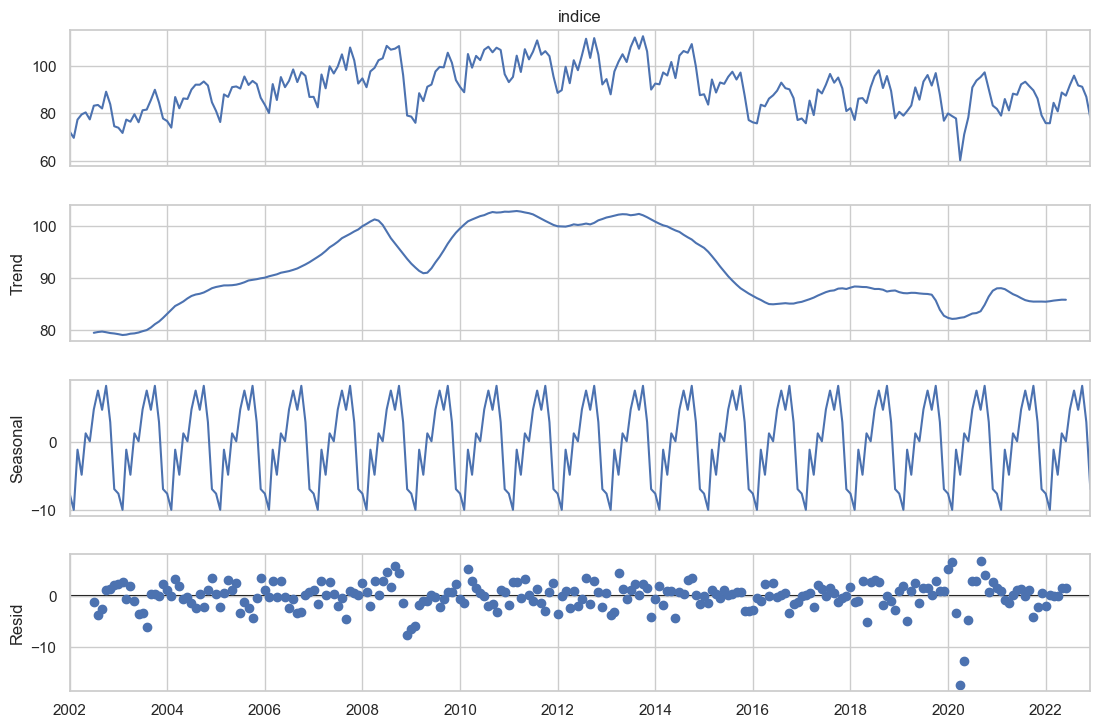

In [59]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposição Aditiva (porque a oscilação parece constante)
decomposicao = seasonal_decompose(df_final['indice'], model='additive', period=12)

# Plotar os 4 gráficos de uma vez
fig = decomposicao.plot()
fig.set_size_inches(12, 8)
plt.show()

Em 2020 teve bastante ruido... pandemia. mas entre 2008-2010 também teve alguma coisa

In [60]:
#COLETA DOS DADOS


# Séries Temporais

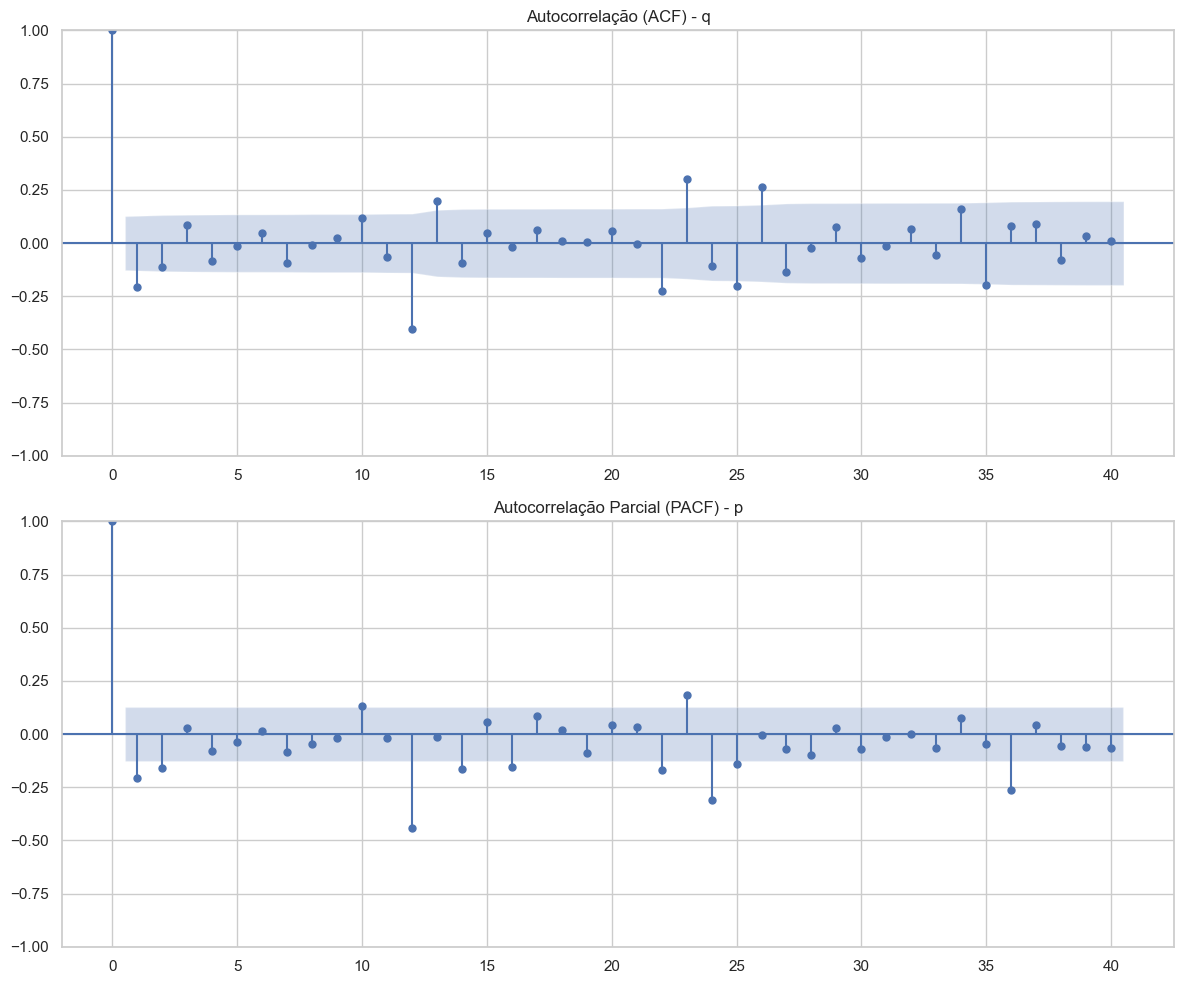

In [18]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Usando a série que você já limpou (Log + Diff + Diff12)
# Lembre-se: usamos a serie_para_modelo (sem NaNs)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ACF: Ajuda a identificar o termo de Média Móvel (q)
plot_acf(serie_para_modelo, lags=40, ax=ax1)
ax1.set_title('Autocorrelação (ACF) - q')

# PACF: Ajuda a identificar o termo de Autorregressão (p)
plot_pacf(serie_para_modelo, lags=40, ax=ax2)
ax2.set_title('Autocorrelação Parcial (PACF) - p')

plt.tight_layout()
plt.show()

In [79]:
import numpy as np

# PASSO 1: Criar a coluna que está faltando
BrasilGeral['Indice_Log'] = np.log(BrasilGeral['Indice'])

# PASSO 2: Agora sim, definir o tamanho do teste (24 meses)
tamanho_teste = 24

# PASSO 3: Separar treino e teste usando a coluna que acabamos de criar
treino = BrasilGeral['Indice_Log'].iloc[:-tamanho_teste]
teste = BrasilGeral['Indice_Log'].iloc[-tamanho_teste:]

print("Coluna 'Indice_Log' criada com sucesso!")
print(f"Treino vai de {treino.index.min()} até {treino.index.max()}")

Coluna 'Indice_Log' criada com sucesso!
Treino vai de 2002-01-01 00:00:00 até 2020-12-01 00:00:00


In [85]:
import sys
!{sys.executable} -m pip install --upgrade statsmodels pmdarima


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
import sys


if 'BrasilGeral' in locals():
    # Recriando o Log e os recortes
    BrasilGeral['Indice_Log'] = np.log(BrasilGeral['Indice'])
    tamanho_teste = 24
    treino = BrasilGeral['Indice_Log'].iloc[:-tamanho_teste]
    
    #Buscar melhor modelo
    try:
        
        modelo_fit = auto_arima(treino, 
                                 seasonal=True, 
                                 m=12,          
                                 stepwise=True, 
                                 trace=True,    
                                 error_action='ignore', 
                                 suppress_warnings=True)

        print("\n--- SUCESSO! RESULTADO DO MODELO ---")
        print(modelo_fit.summary())
        
    except NameError:
        print(NameError)
    except Exception as e:
        print(f"Ocorreu um erro : {e}")
else:
    print("Outro erro")

Dados preparados. Iniciando busca pelo melhor modelo...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=-786.809, Time=4.18 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-571.241, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-756.954, Time=0.72 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-677.515, Time=0.75 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-573.222, Time=0.03 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=-690.741, Time=1.86 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=-761.128, Time=1.80 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=-782.072, Time=3.35 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=inf, Time=4.73 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=-591.238, Time=0.81 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=-712.016, Time=2.62 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=-774.989, Time=2.73 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=-801.525, Time=4.28 sec
 ARIMA(1,1,2)(2,0,2)[12] intercept 